## EDA

### Target Analysis

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/ecommerce_customer_churn_dataset.csv")

In [4]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [5]:
df.shape

(50000, 25)

Text(0.5, 1.0, 'customer churn distribution')

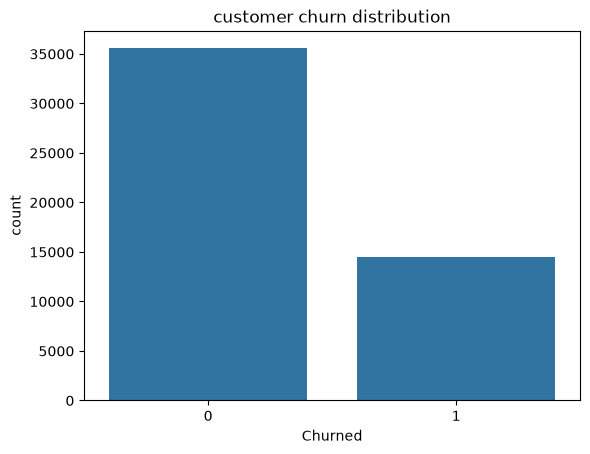

In [7]:
# target analysis

sns.countplot(data=df, x="Churned")

plt.title("customer churn distribution")

In [10]:
# count and percentage

print(df['Churned'].value_counts())

print(df['Churned'].value_counts(normalize=True)*100)

Churned
0    35550
1    14450
Name: count, dtype: int64
Churned
0    71.1
1    28.9
Name: proportion, dtype: float64


In [15]:
# numeric and categorical feature

num_cols = df.select_dtypes(include="number").columns.drop('Churned')
# num_cols


cat_cols = df.select_dtypes(include="string").columns
# cat_cols

Index(['Gender', 'Country', 'City', 'Signup_Quarter'], dtype='str')

In [17]:
# numeric columns analysis

df[num_cols].describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,46500.000000,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,41.997485,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,21.373642,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,0.240000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,25.300000,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,40.200000,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,57.000000,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,116.640000,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000


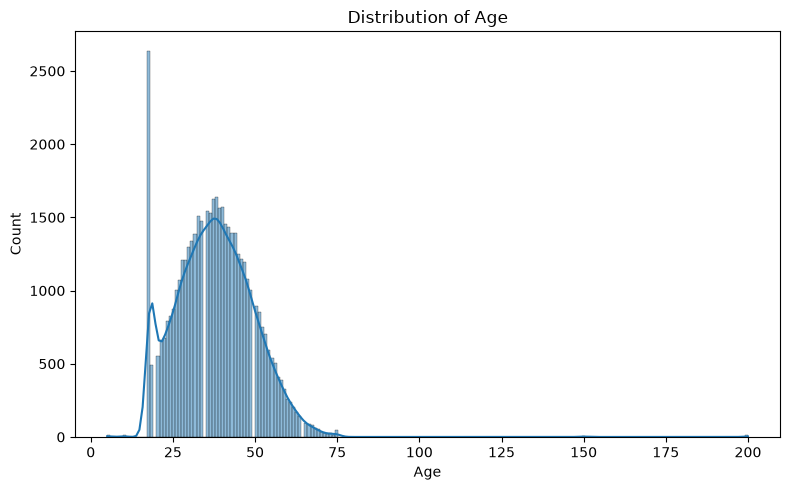

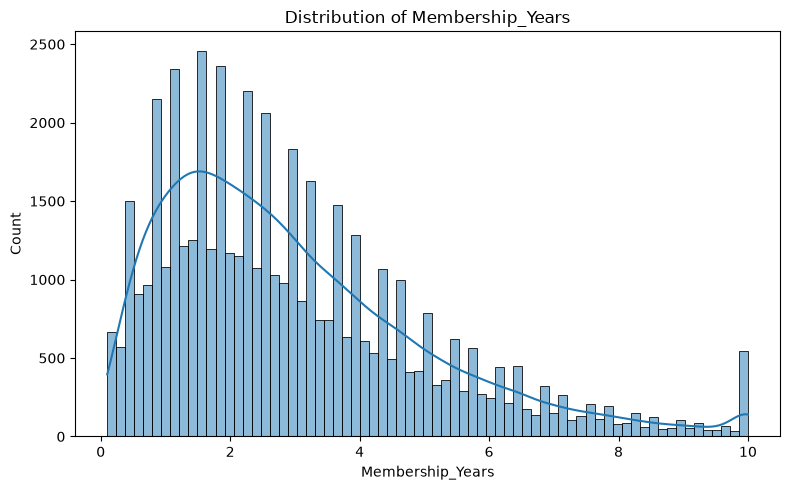

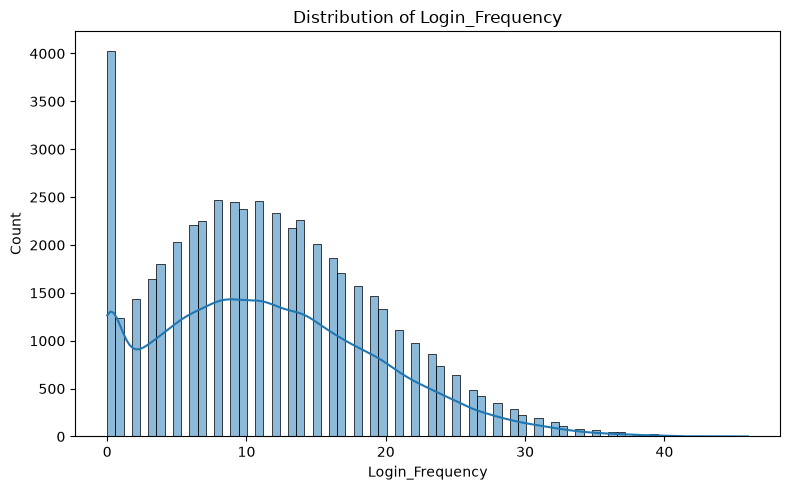

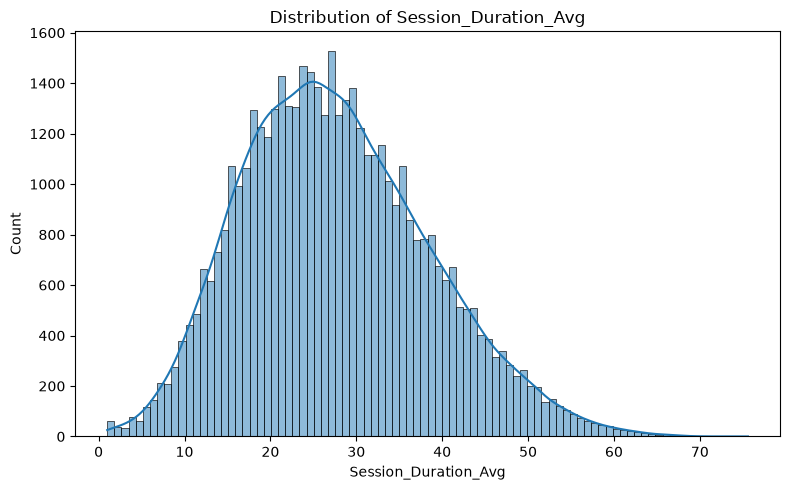

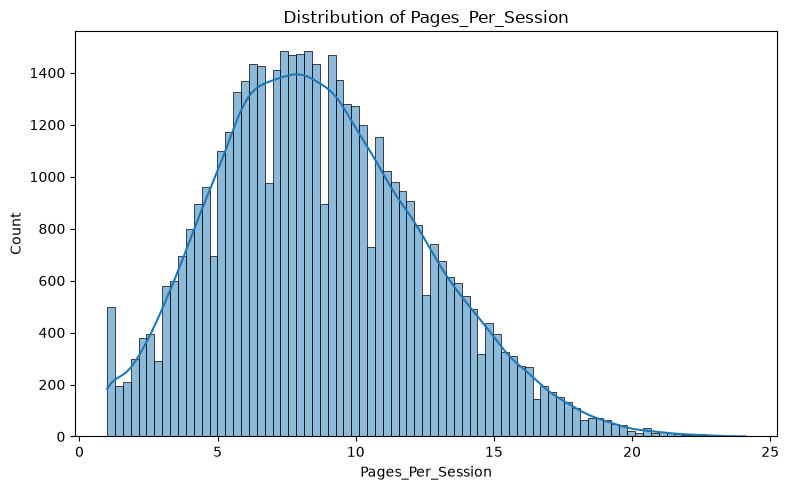

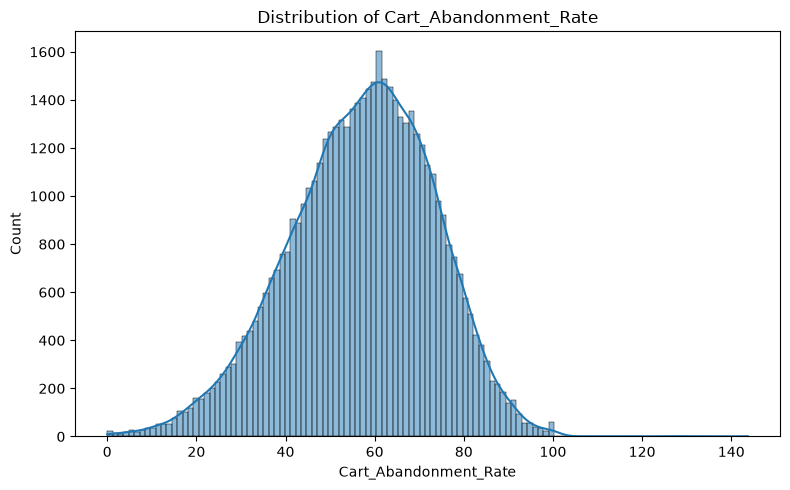

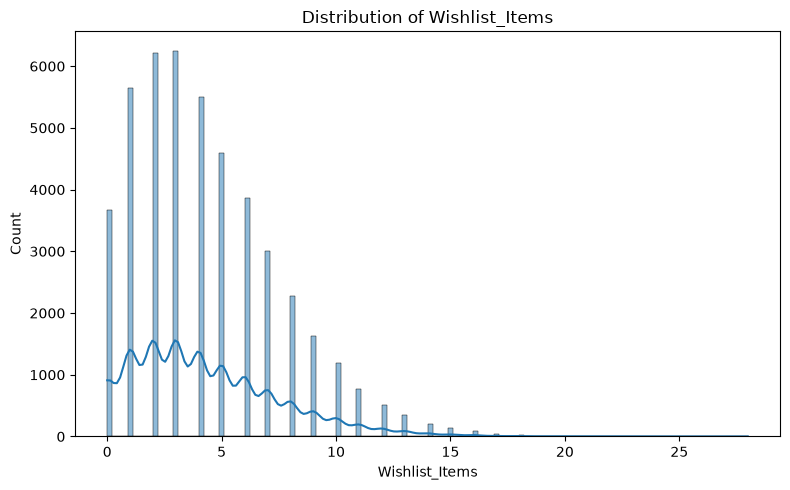

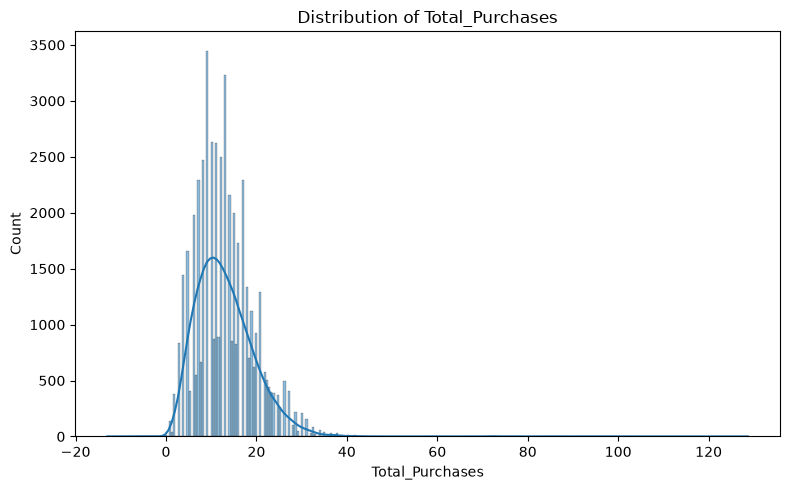

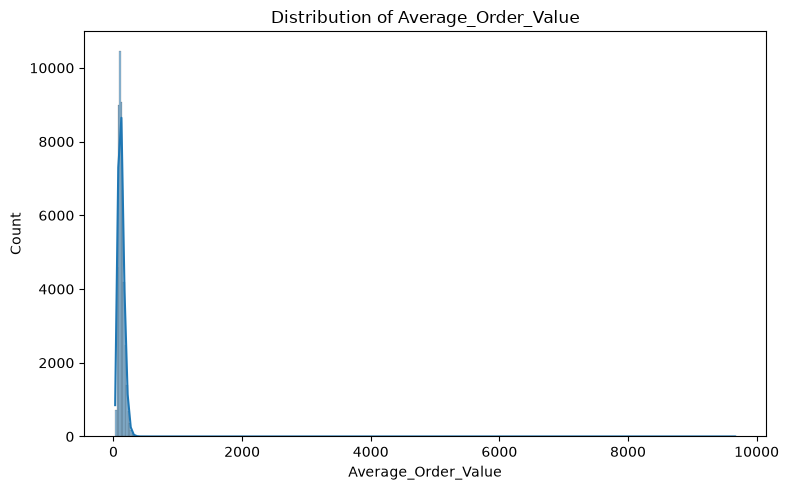

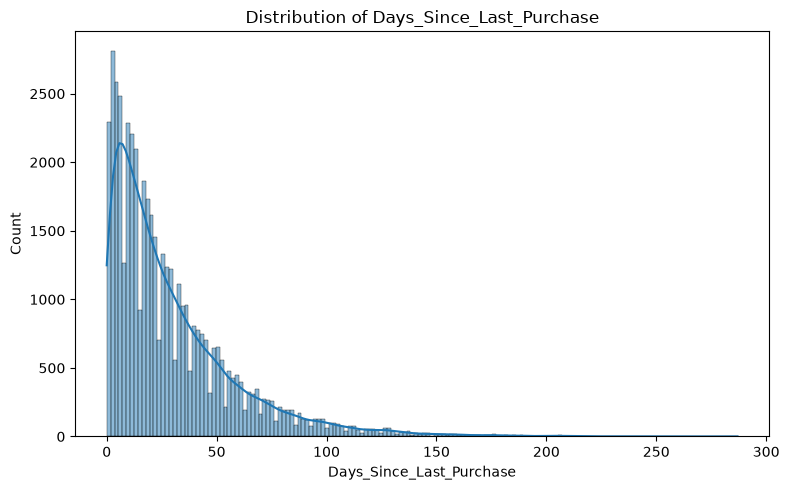

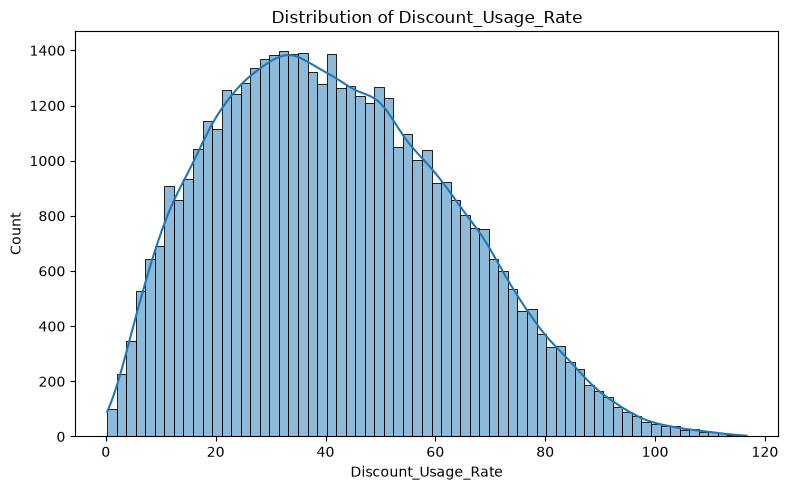

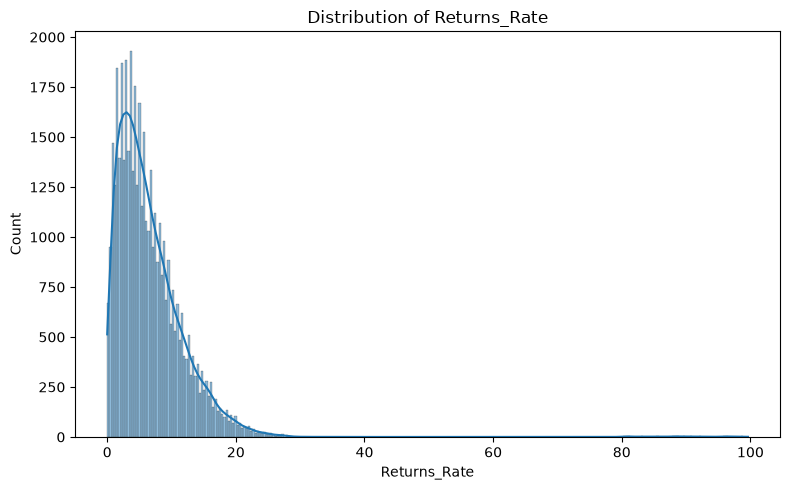

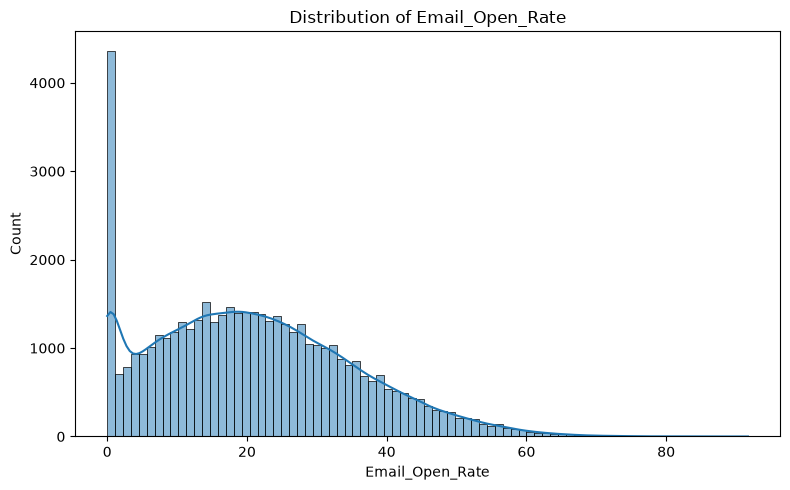

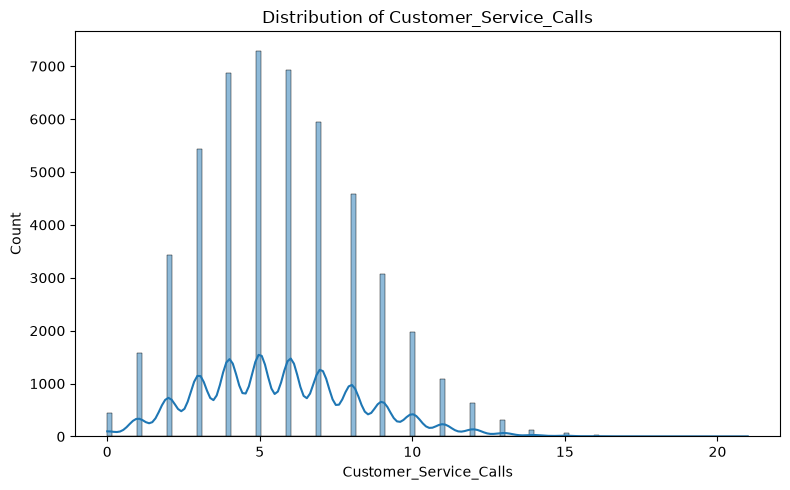

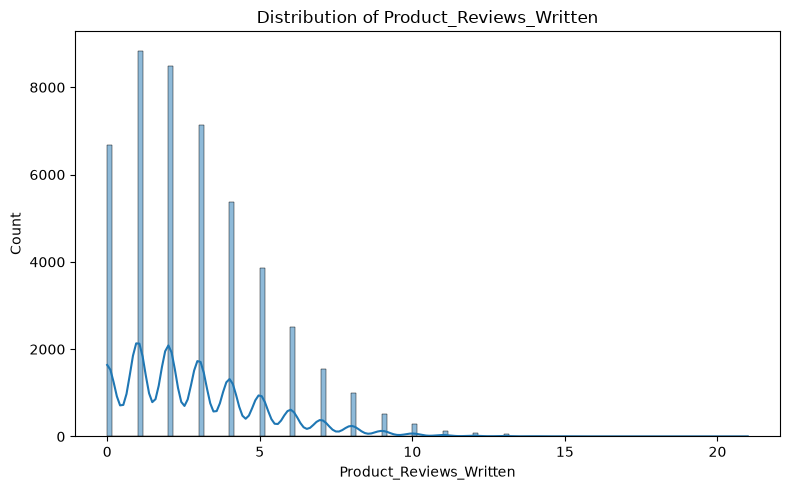

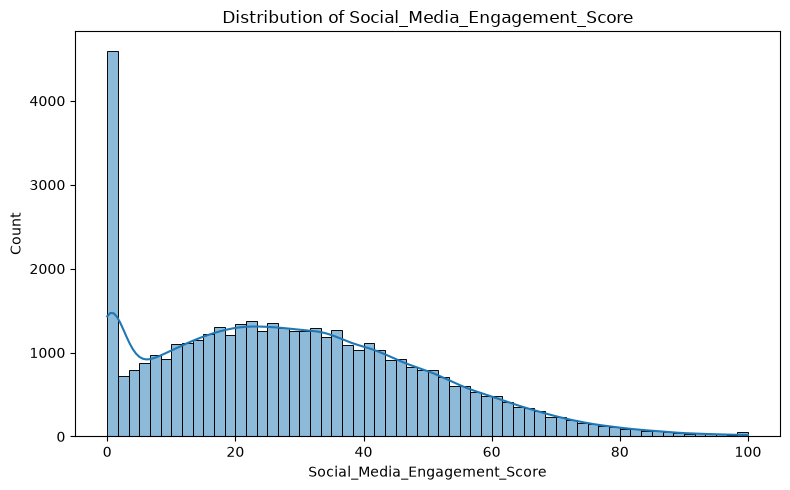

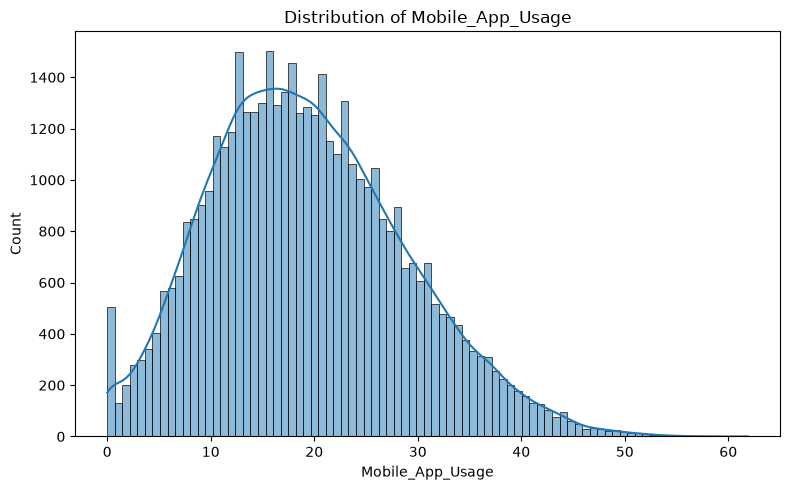

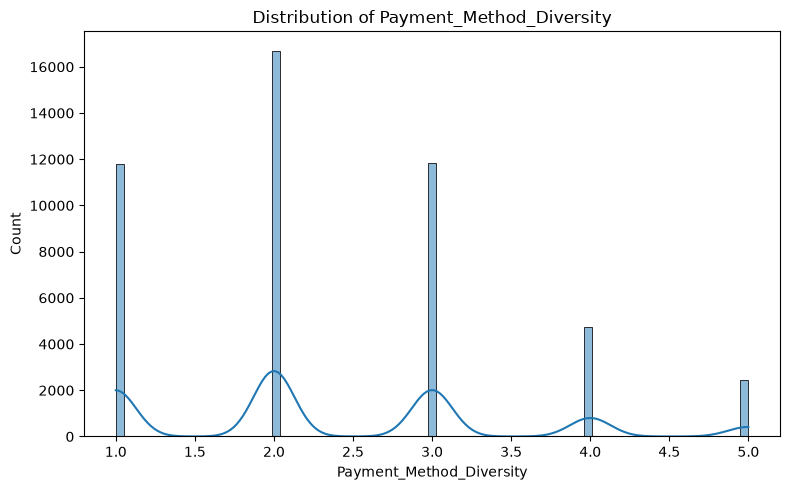

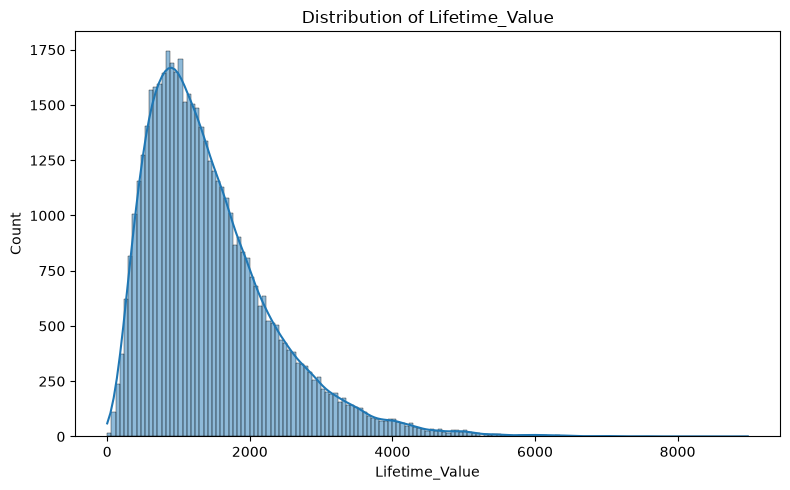

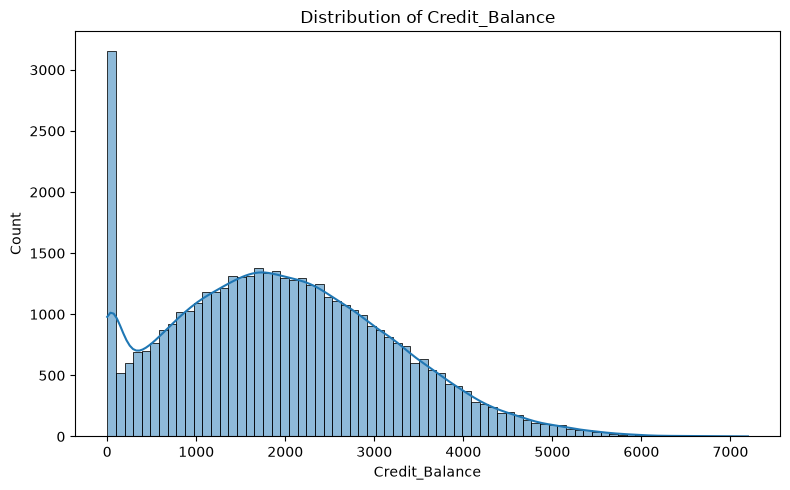

In [19]:
for col in num_cols:
    plt.figure(figsize=(8,5))

    sns.histplot(data=df, x=col, kde=True)

    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

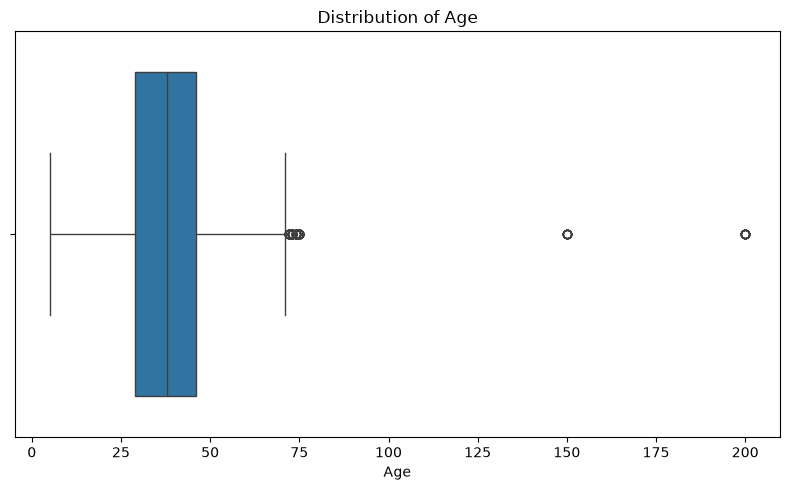

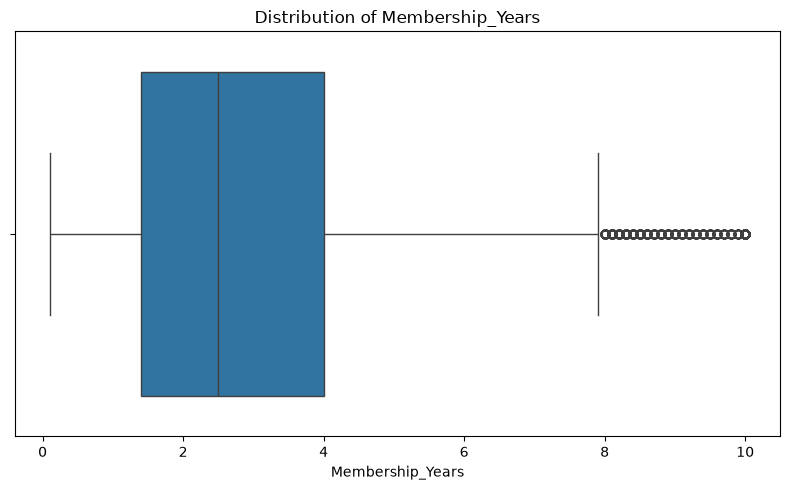

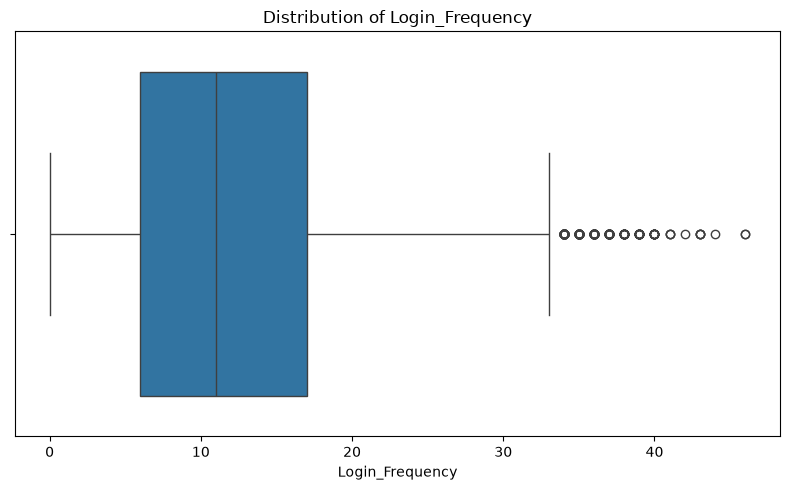

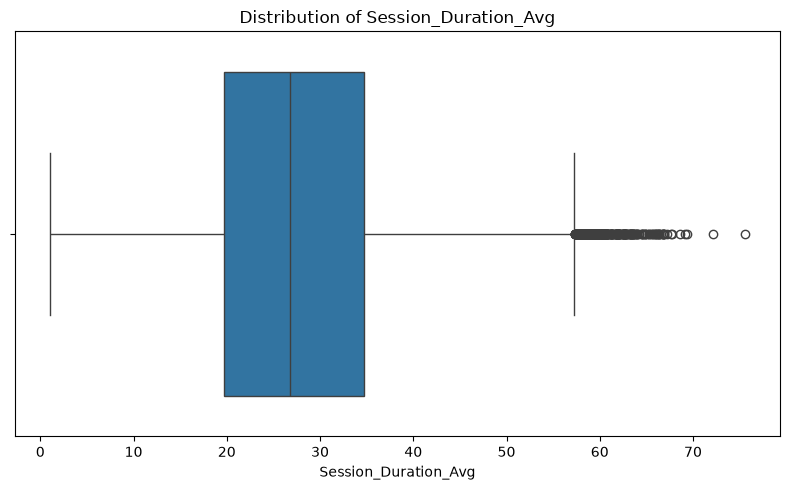

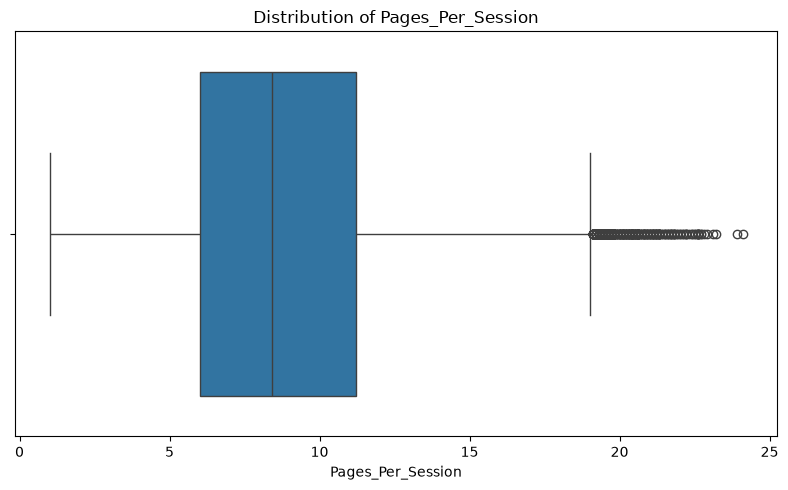

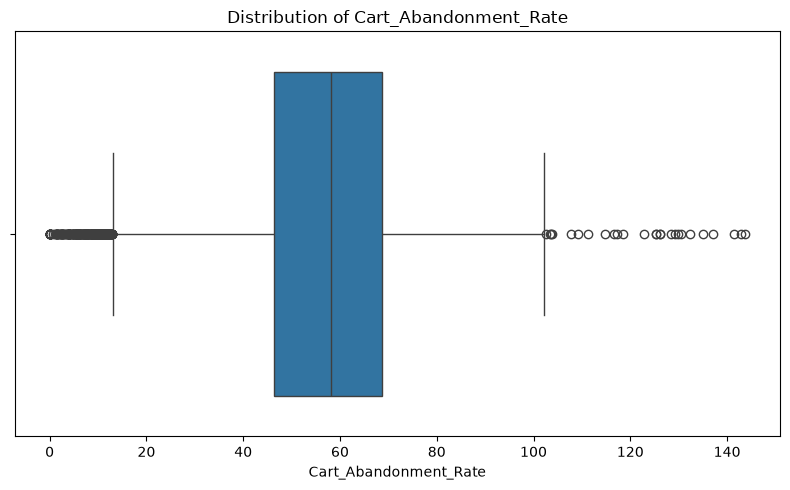

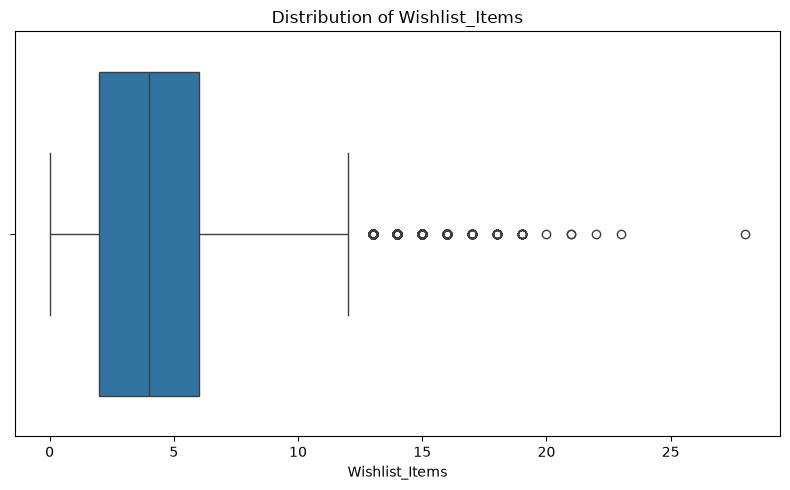

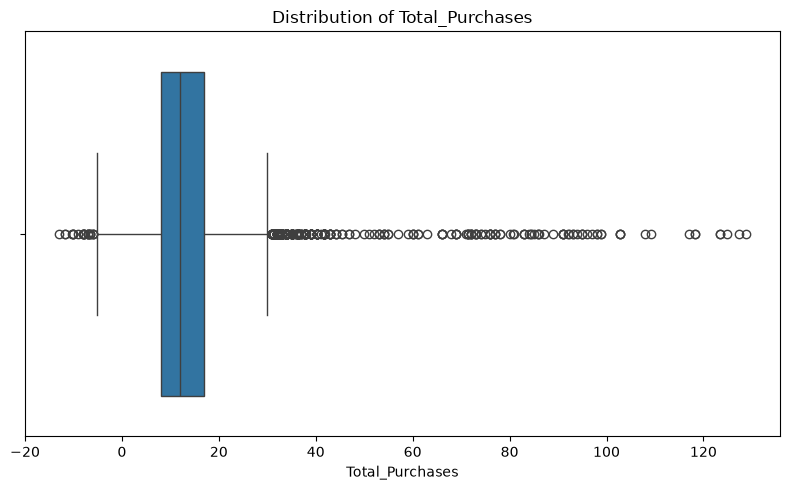

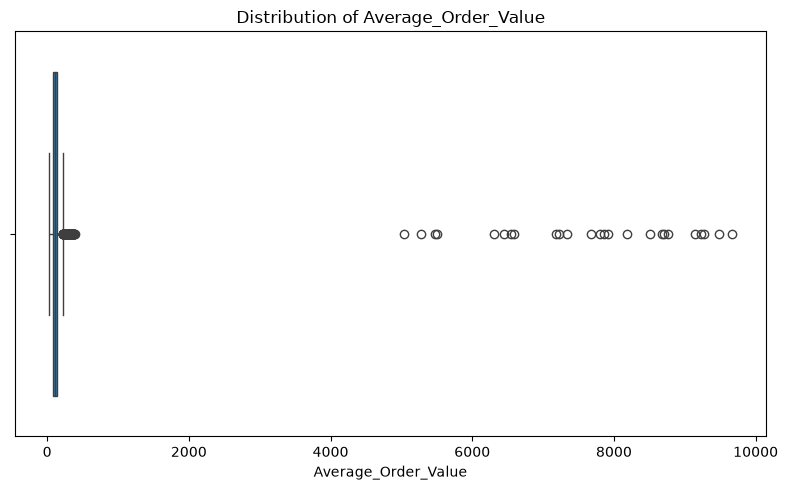

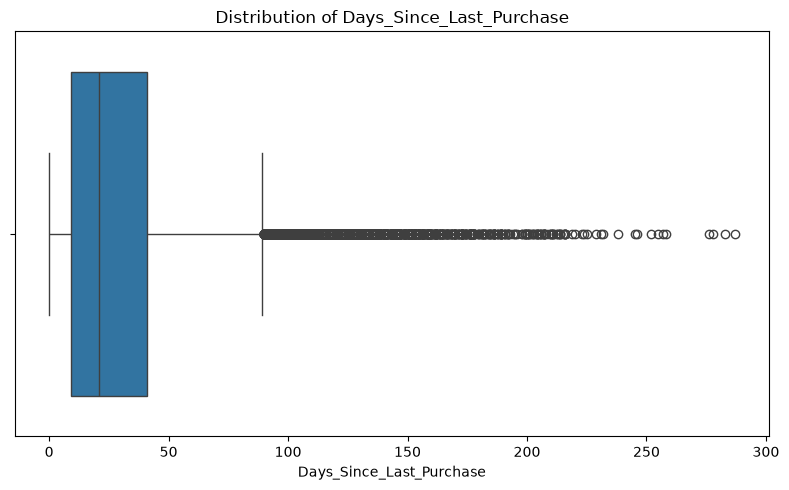

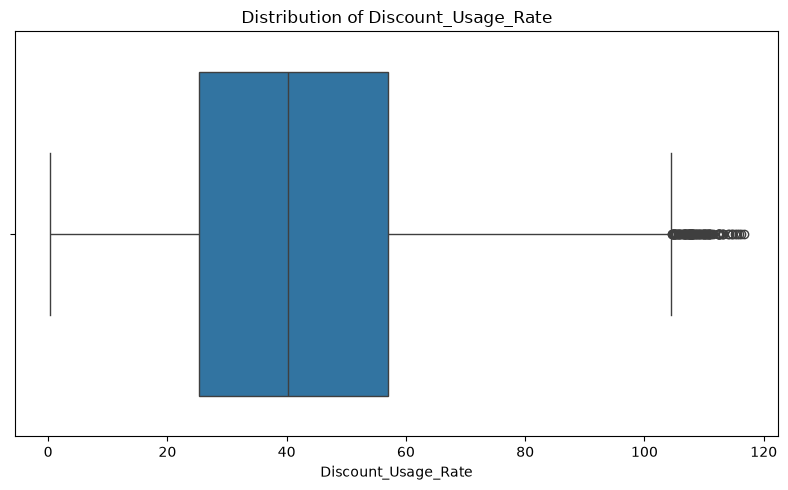

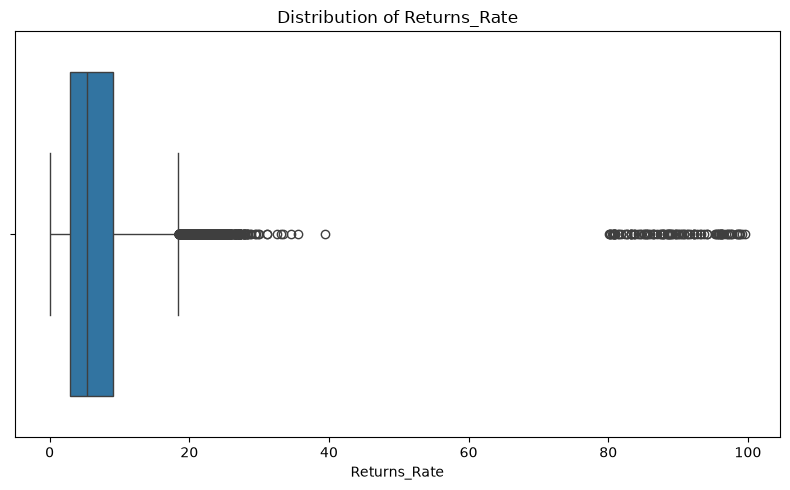

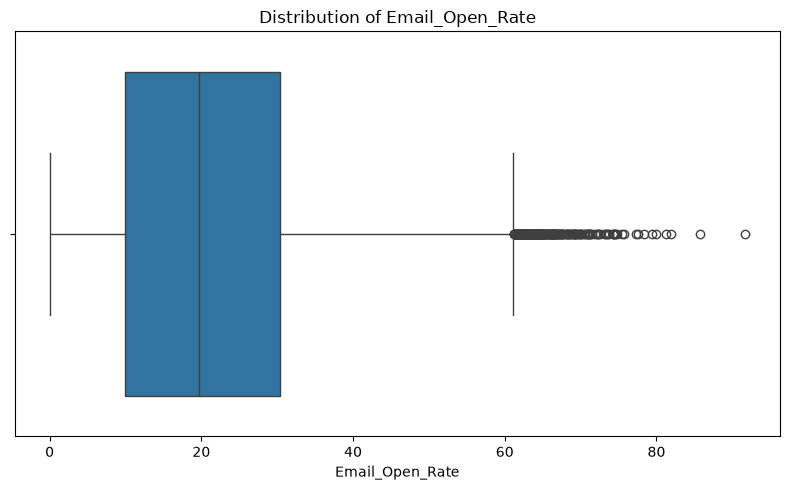

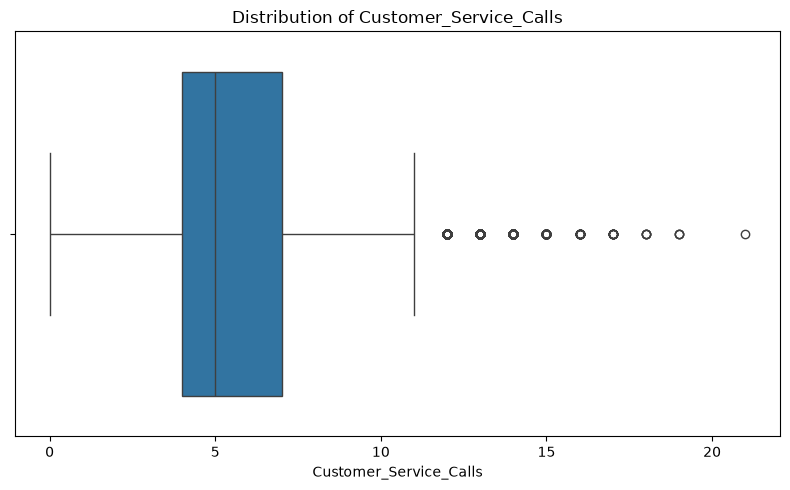

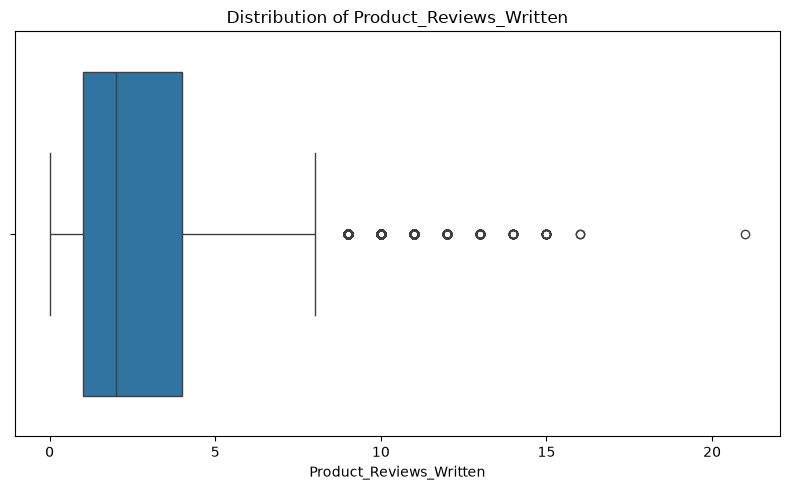

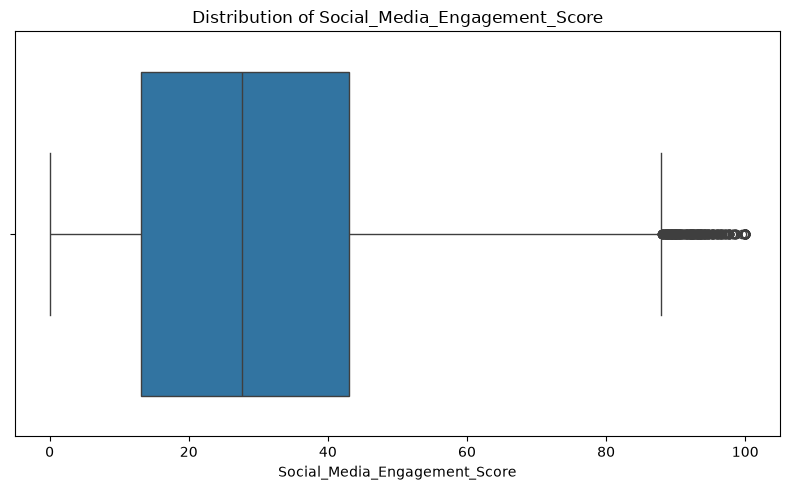

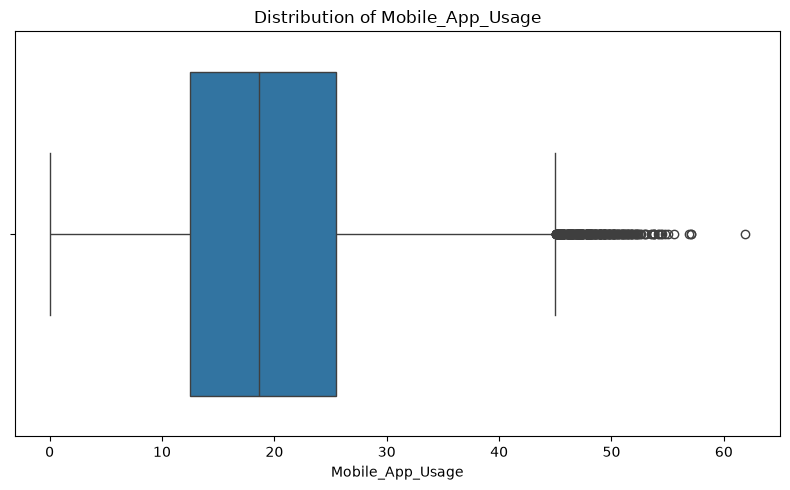

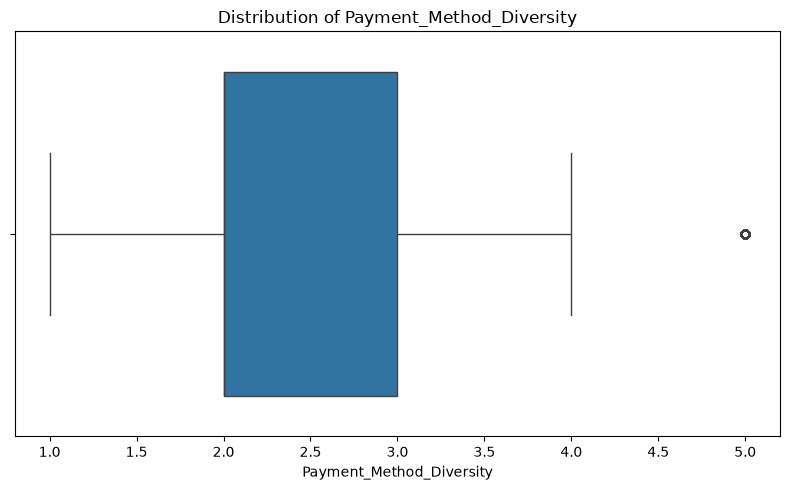

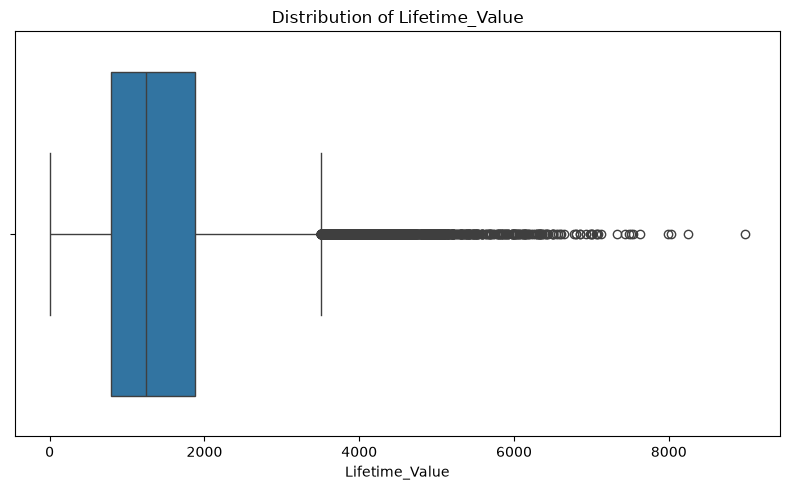

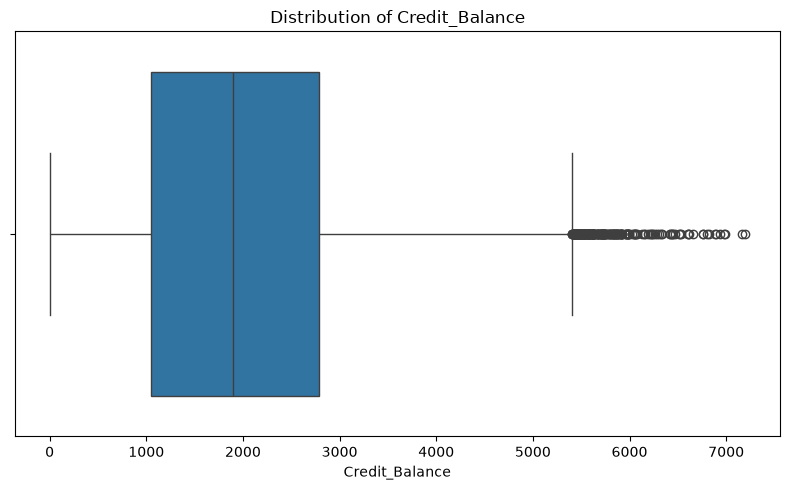

In [20]:
# boxplot 

for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

In [21]:
for col in cat_cols:
    print(f"Value count of {col} :\n")
    print(df[col].value_counts())


Value count of Gender :

Gender
Female    25116
Male      23947
Other       937
Name: count, dtype: int64
Value count of Country :

Country
USA          17384
UK            7534
Canada        6023
Germany       4925
Australia     4061
France        4013
India         3512
Japan         2548
Name: count, dtype: int64
Value count of City :

City
Houston        3549
Phoenix        3490
New York       3477
Chicago        3475
Los Angeles    3393
Manchester     1576
Birmingham     1535
Leeds          1529
London         1458
Glasgow        1436
Montreal       1247
Toronto        1209
Calgary        1204
Ottawa         1182
Vancouver      1181
Cologne        1033
Hamburg        1026
Berlin         1013
Munich          960
Frankfurt       893
Lyon            830
Sydney          828
Adelaide        817
Perth           817
Toulouse        815
Melbourne       805
Nice            799
Brisbane        794
Marseille       793
Paris           776
Chennai         736
Bangalore       698
Mumbai        

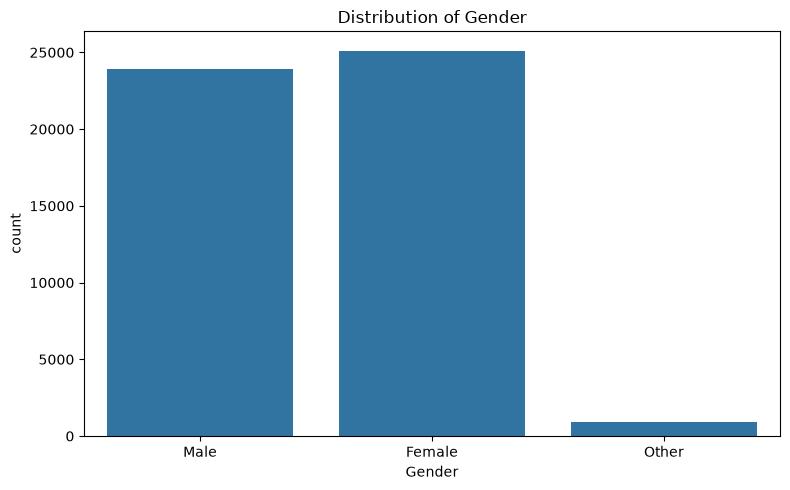

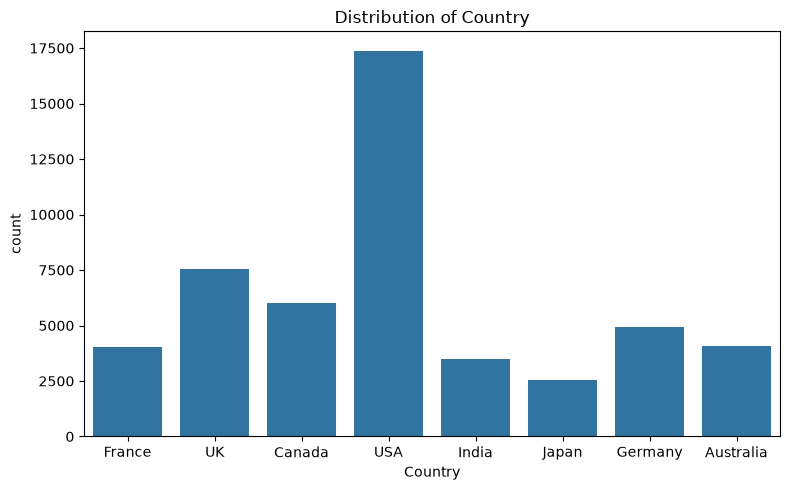

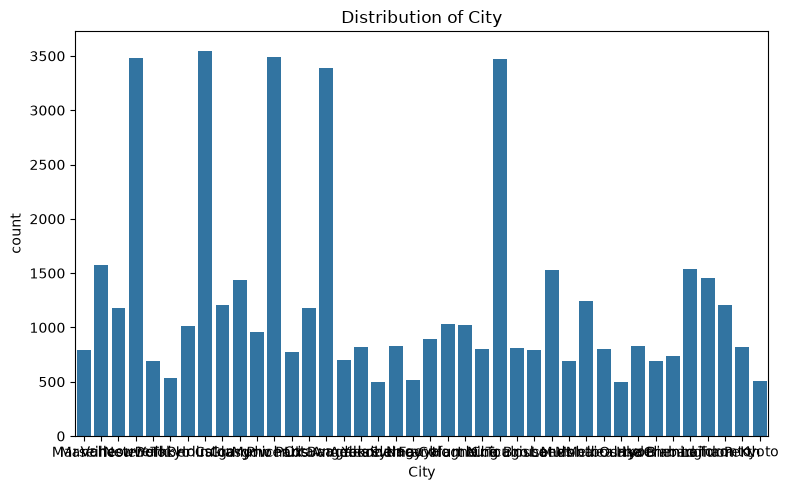

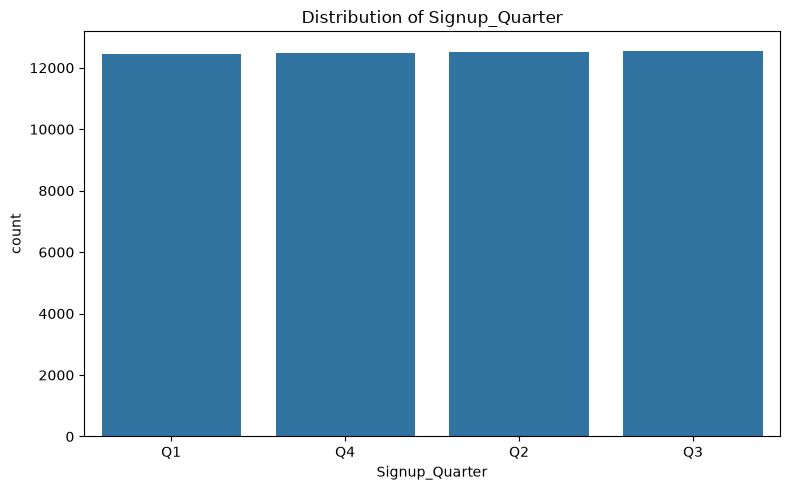

In [22]:
# categorical analysis

for col in cat_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


### Bivarient Analysis

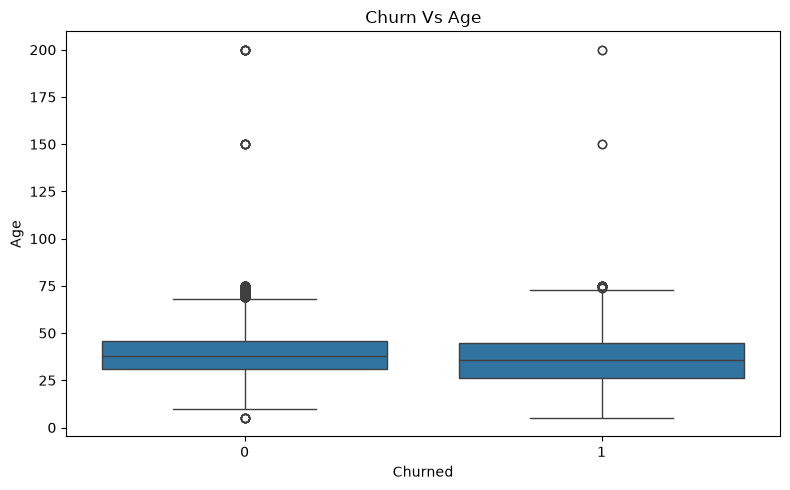

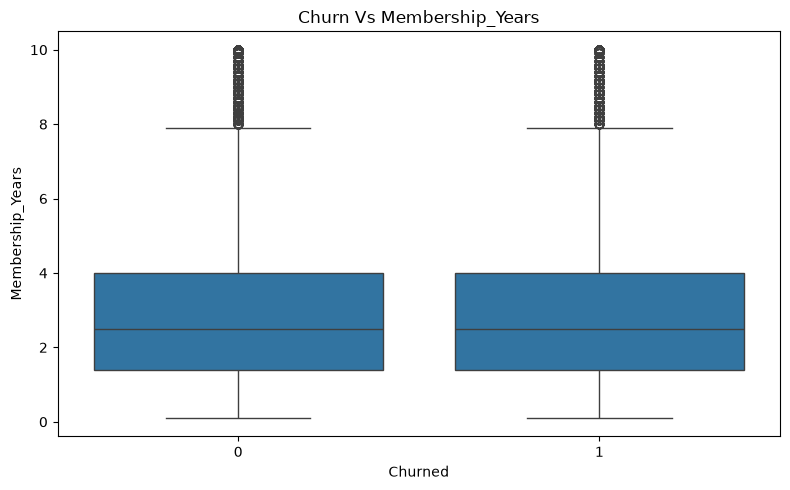

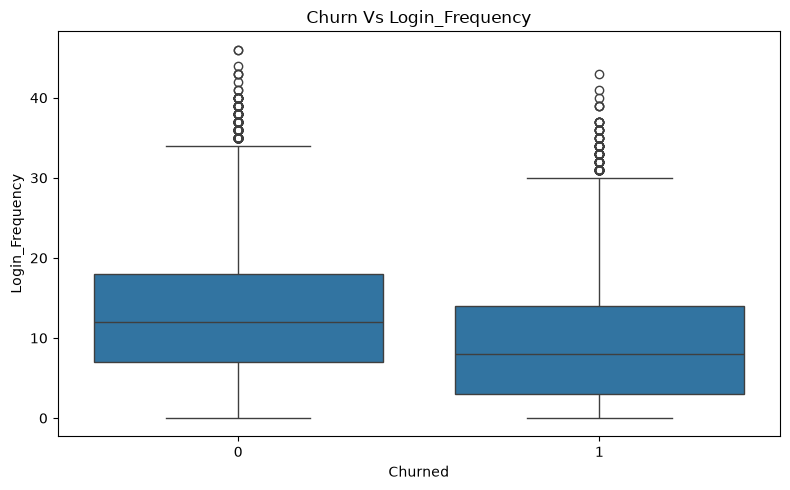

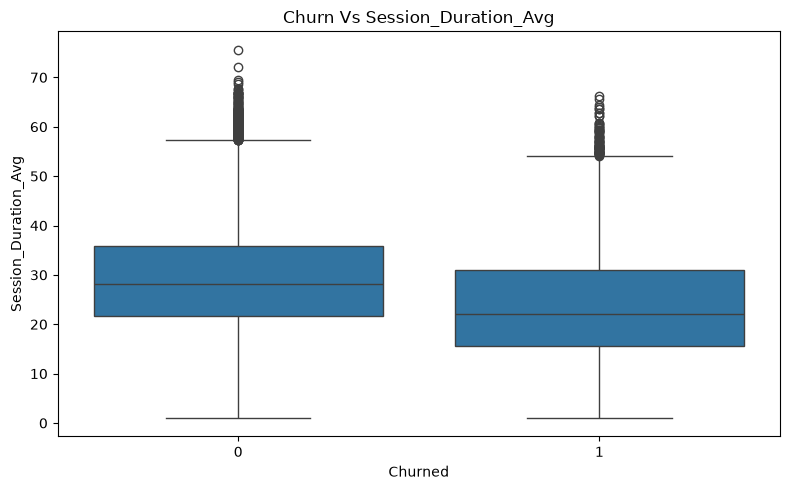

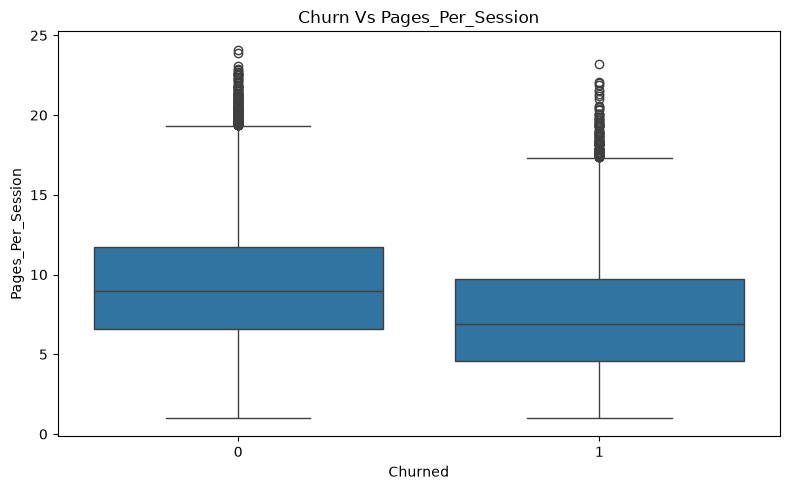

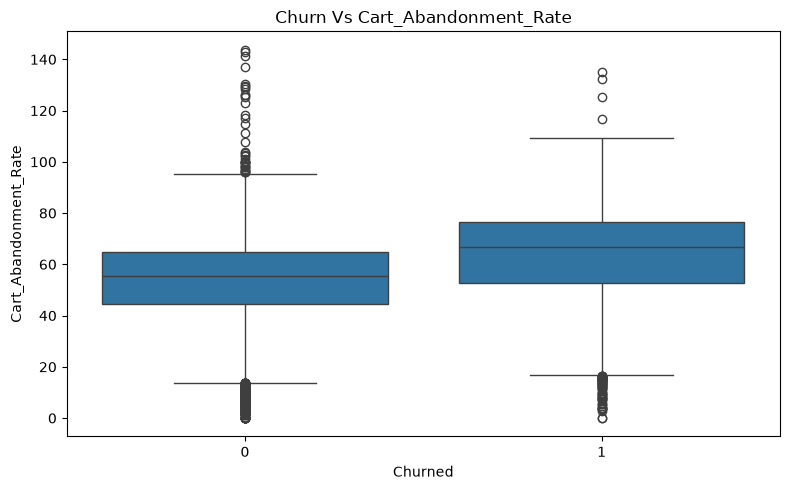

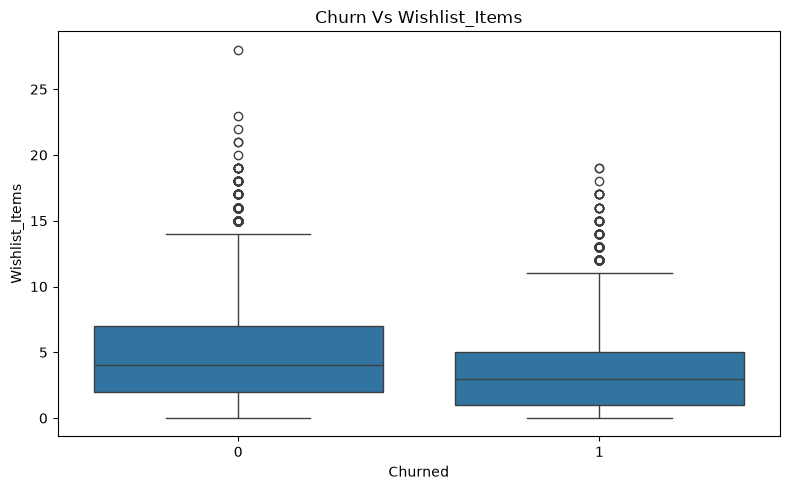

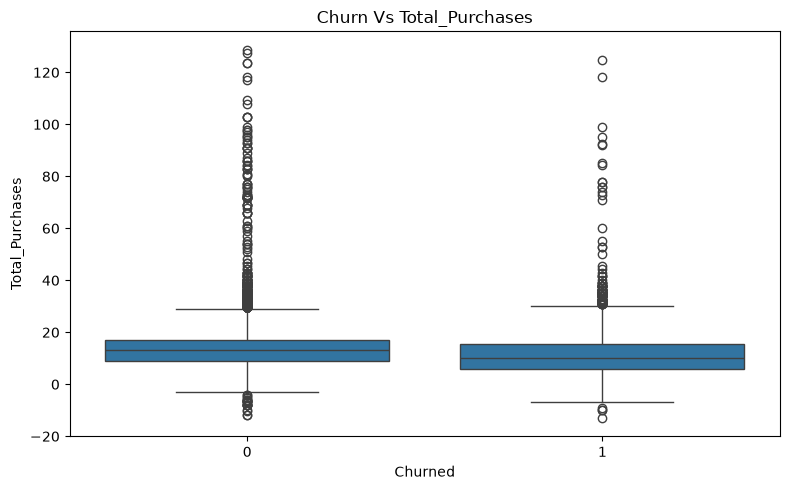

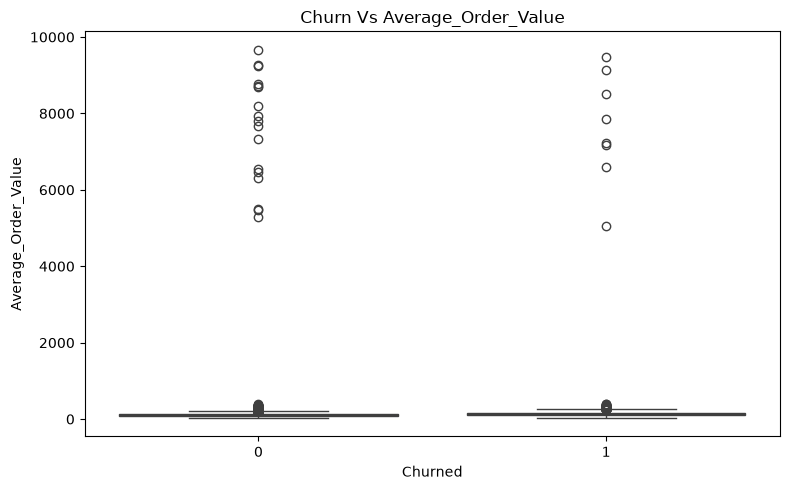

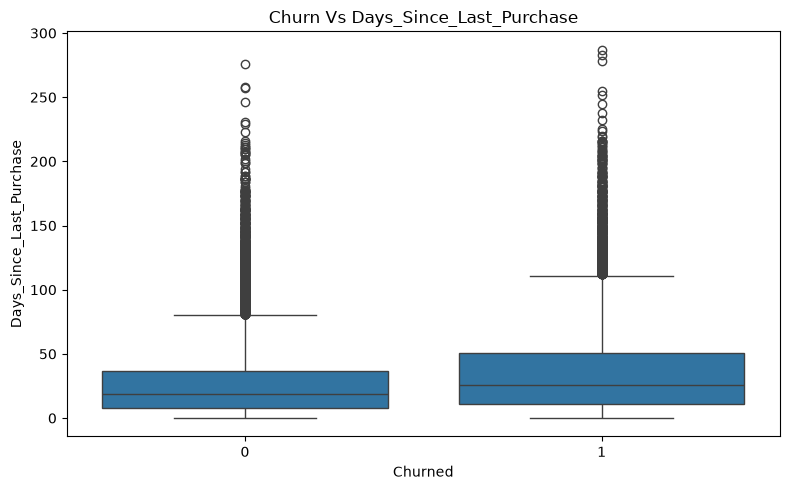

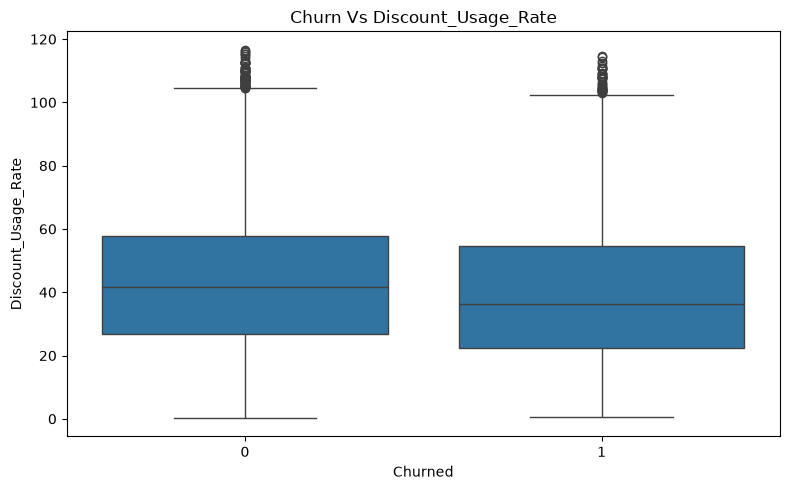

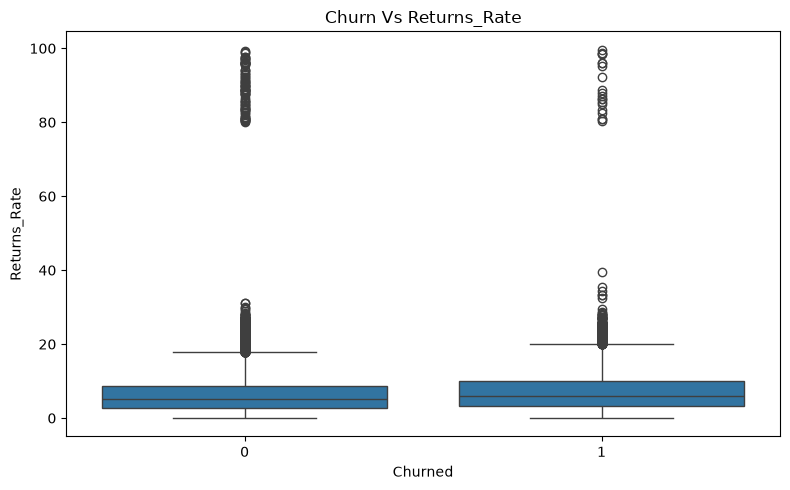

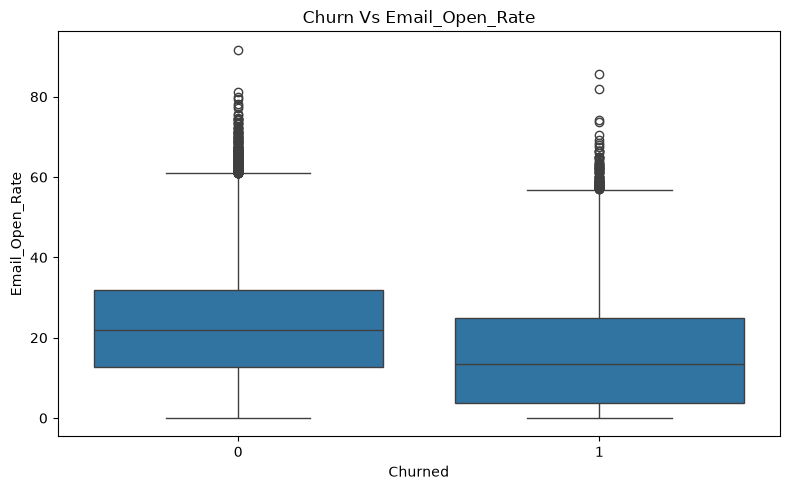

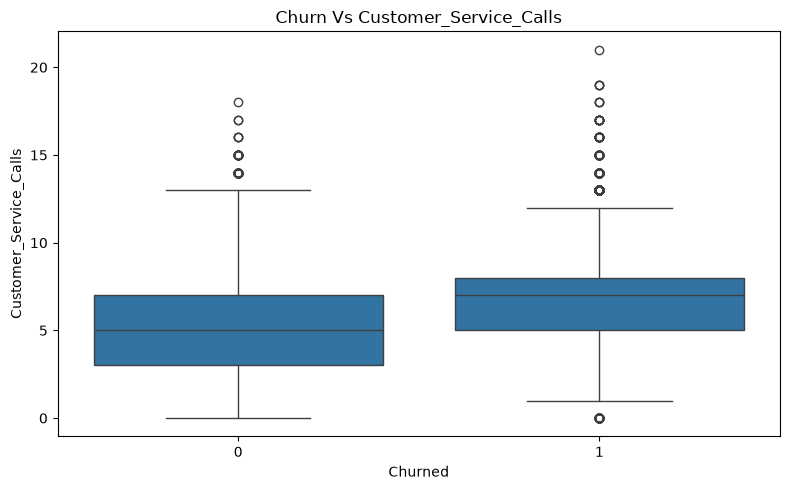

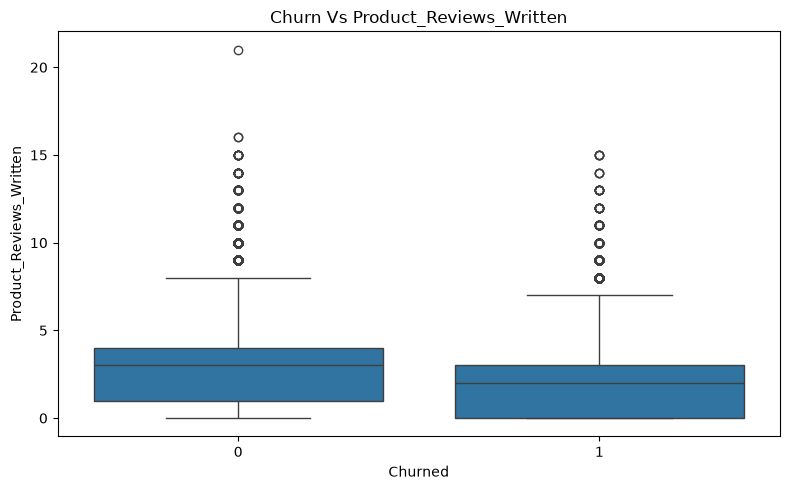

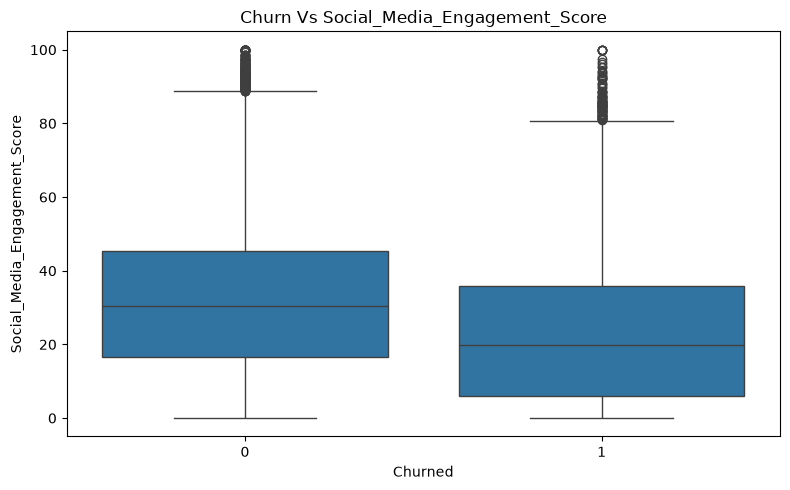

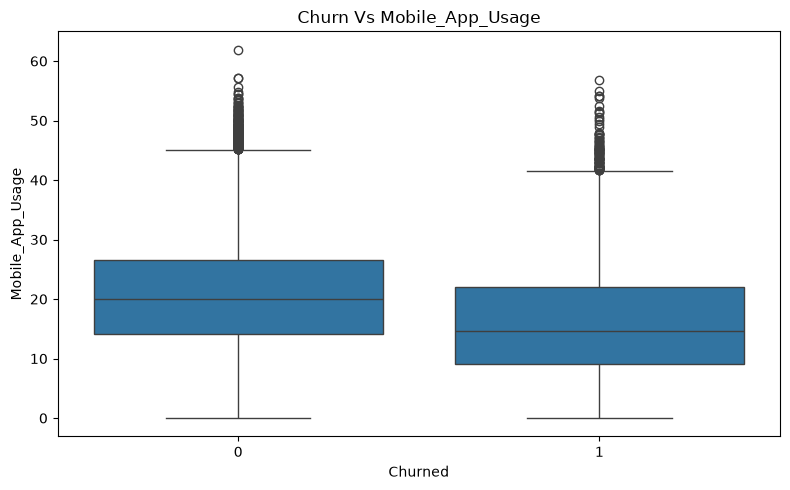

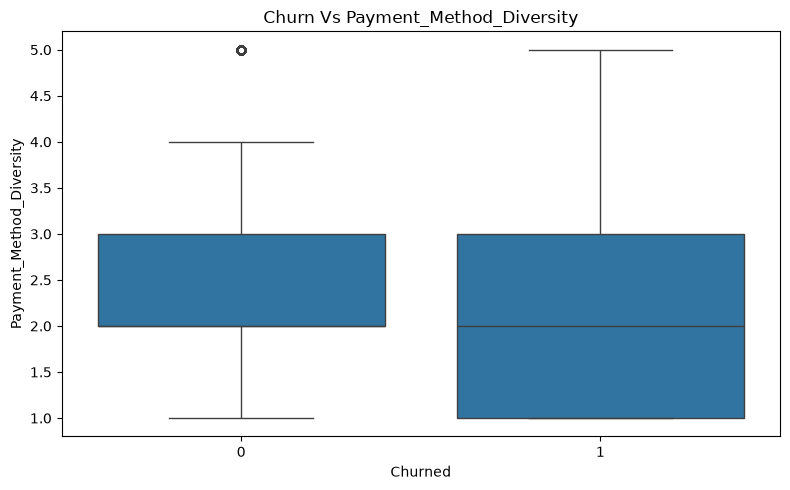

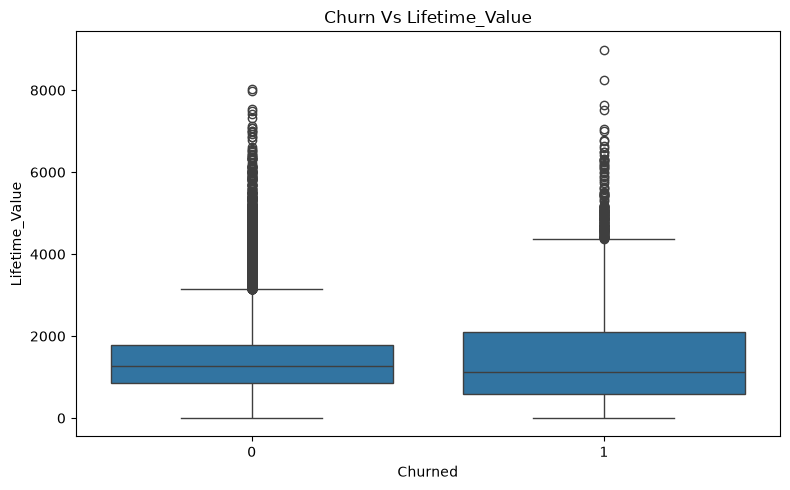

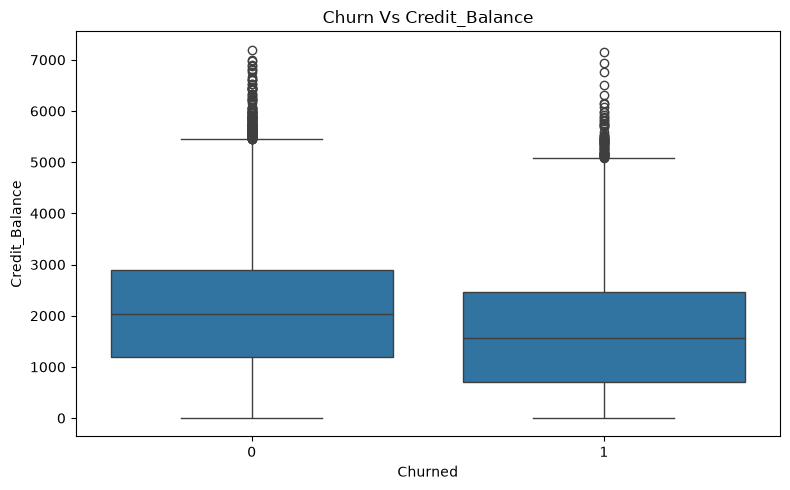

In [24]:
# target vs numeric

for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x="Churned", y=col)
    plt.title(f"Churn Vs {col}")
    plt.tight_layout()
    plt.show()

In [31]:
# target vs Category

for col in cat_cols:
    print(f"Churned Vs {col}\n")
    count_table=pd.crosstab(
        df[col],
        df["Churned"]
    )

    count_table.columns = ['Active',"churned"]

    print(count_table)



    churn_rate = (df.groupby(col)['Churned'].mean().mul(100).sort_values(ascending=False))

    print(churn_rate)



Churned Vs Gender

        Active  churned
Gender                 
Female   17839     7277
Male     17067     6880
Other      644      293
Gender
Other     31.270011
Female    28.973563
Male      28.730112
Name: Churned, dtype: float64
Churned Vs Country

           Active  churned
Country                   
Australia    2847     1214
Canada       4255     1768
France       2918     1095
Germany      3505     1420
India        2493     1019
Japan        1839      709
UK           5365     2169
USA         12328     5056
Country
Australia    29.894115
Canada       29.354142
USA          29.084215
India        29.014806
Germany      28.832487
UK           28.789488
Japan        27.825746
France       27.286319
Name: Churned, dtype: float64
Churned Vs City

             Active  churned
City                        
Adelaide        605      212
Bangalore       508      190
Berlin          718      295
Birmingham     1089      446
Brisbane        555      239
Calgary         844      360
Che

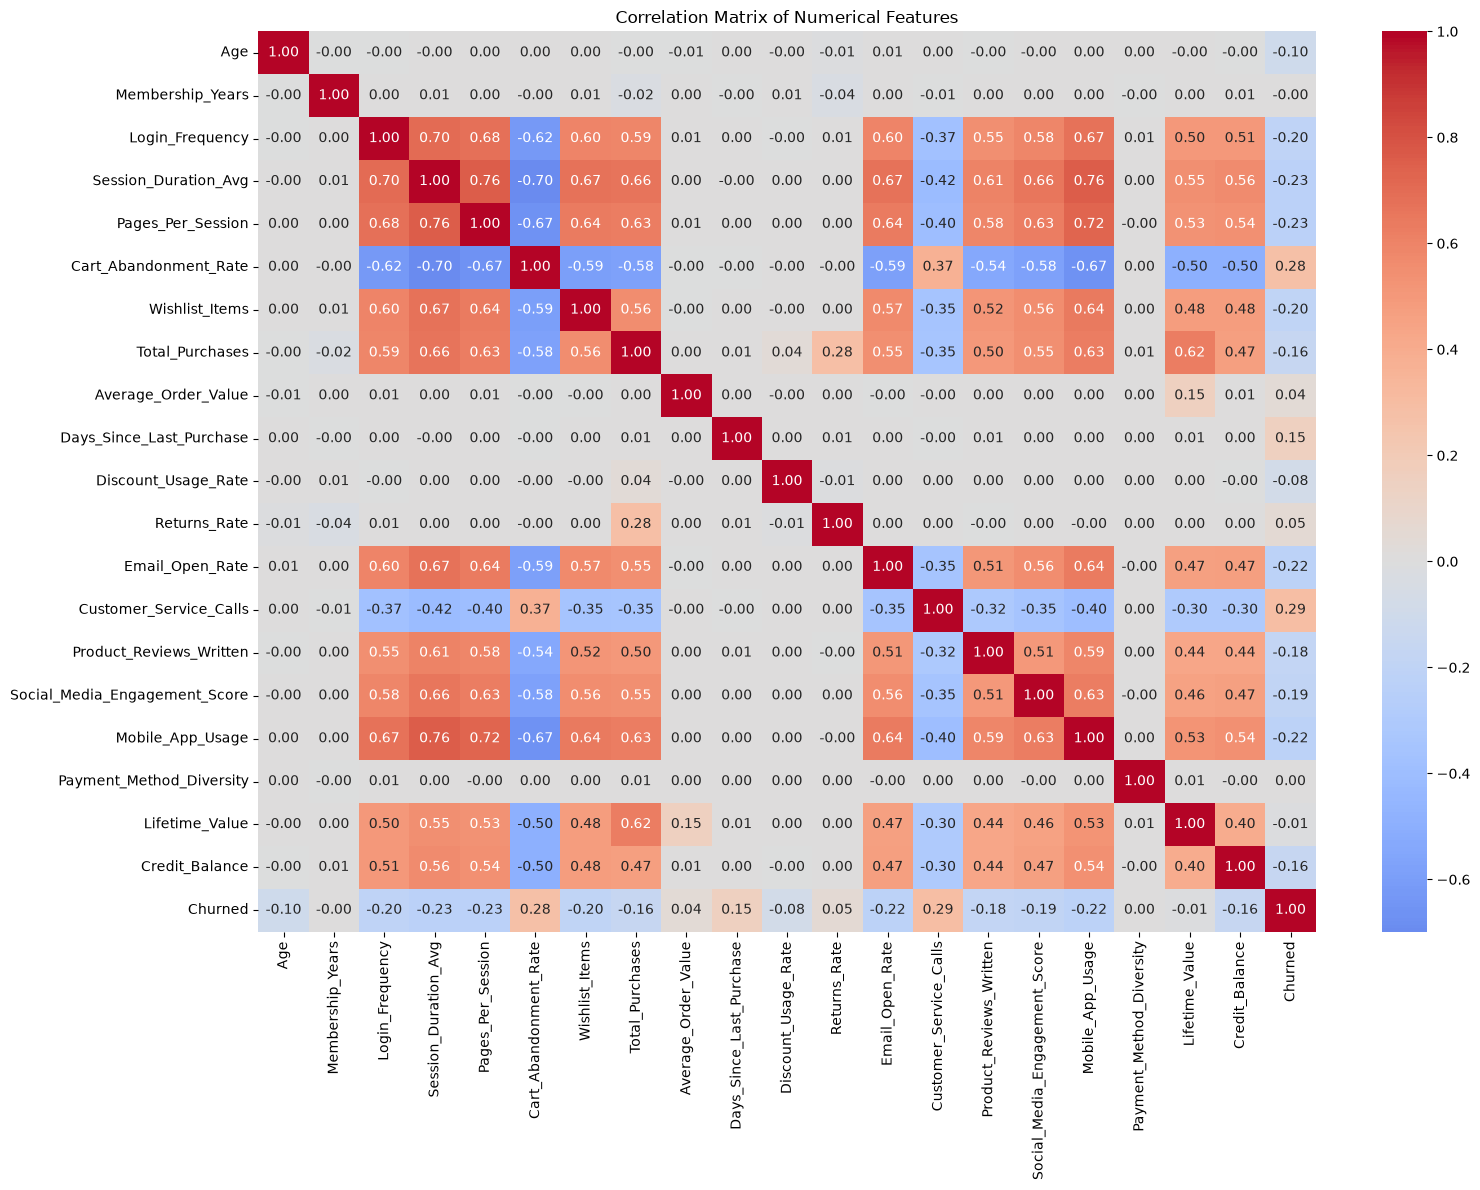

In [ ]:
# correlation between features

import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include="number").columns

plt.figure(figsize=(16, 12))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [35]:
numeric_cols = df.select_dtypes(include="number").columns

corr_matrix = df[numeric_cols].corr()

corr_pairs = (
    corr_matrix
    .where(~np.tril(np.ones(corr_matrix.shape)).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

strong_corr = corr_pairs[abs(corr_pairs) >= 0.7]

print(strong_corr.round(3))

Session_Duration_Avg  Pages_Per_Session       0.756
                      Mobile_App_Usage        0.756
Pages_Per_Session     Mobile_App_Usage        0.724
Login_Frequency       Session_Duration_Avg    0.704
dtype: float64


In [40]:
# correlation between features and target

numeric_cols = df.select_dtypes(include="number").columns

target_corr = (
    df[numeric_cols]
    .corr()["Churned"]
    .drop("Churned")
    .sort_values(key=abs, ascending=False)
)

print(target_corr.round(3))

Customer_Service_Calls           0.291
Cart_Abandonment_Rate            0.278
Pages_Per_Session               -0.232
Session_Duration_Avg            -0.228
Mobile_App_Usage                -0.223
Email_Open_Rate                 -0.222
Login_Frequency                 -0.204
Wishlist_Items                  -0.198
Social_Media_Engagement_Score   -0.192
Product_Reviews_Written         -0.181
Total_Purchases                 -0.160
Credit_Balance                  -0.157
Days_Since_Last_Purchase         0.153
Age                             -0.103
Discount_Usage_Rate             -0.077
Returns_Rate                     0.054
Average_Order_Value              0.042
Lifetime_Value                  -0.011
Payment_Method_Diversity         0.005
Membership_Years                -0.001
Name: Churned, dtype: float64
